In [2]:
import osmnx as ox
from shapely import Polygon
import matplotlib.pyplot as plt
from haversine import haversine
from collections import defaultdict
import pandas as pd
from utils import *
from utils import bd09_to_gcj02
import networkx as nx
from docx.api import Document
from datetime import datetime
import shutil
import random
import json
random.seed(0)

In [3]:
"""
obtain data for region 1
"""
dire = "data/static_3.json"
with open(dire, 'r', encoding='utf-8') as outfile:
    res_dict = json.load(outfile)
stat_dict = res_dict["stations"]
id2name = {dic["station_id"]: dic["station_name"] for dic in stat_dict}
ids = [dic["station_id"] for dic in stat_dict]

locBD = [(dic["station_lon"], dic["station_lat"]) for dic in stat_dict]
locGCJ = [bd09_to_gcj02(coord[0], coord[1]) for coord in locBD]
locWGS = [trans_coord(coord[0], coord[1]) for coord in locGCJ]
lons, lats = list(zip(*locWGS))
id2loc = {ids[i]: locWGS[i] for i in range(len(ids))}

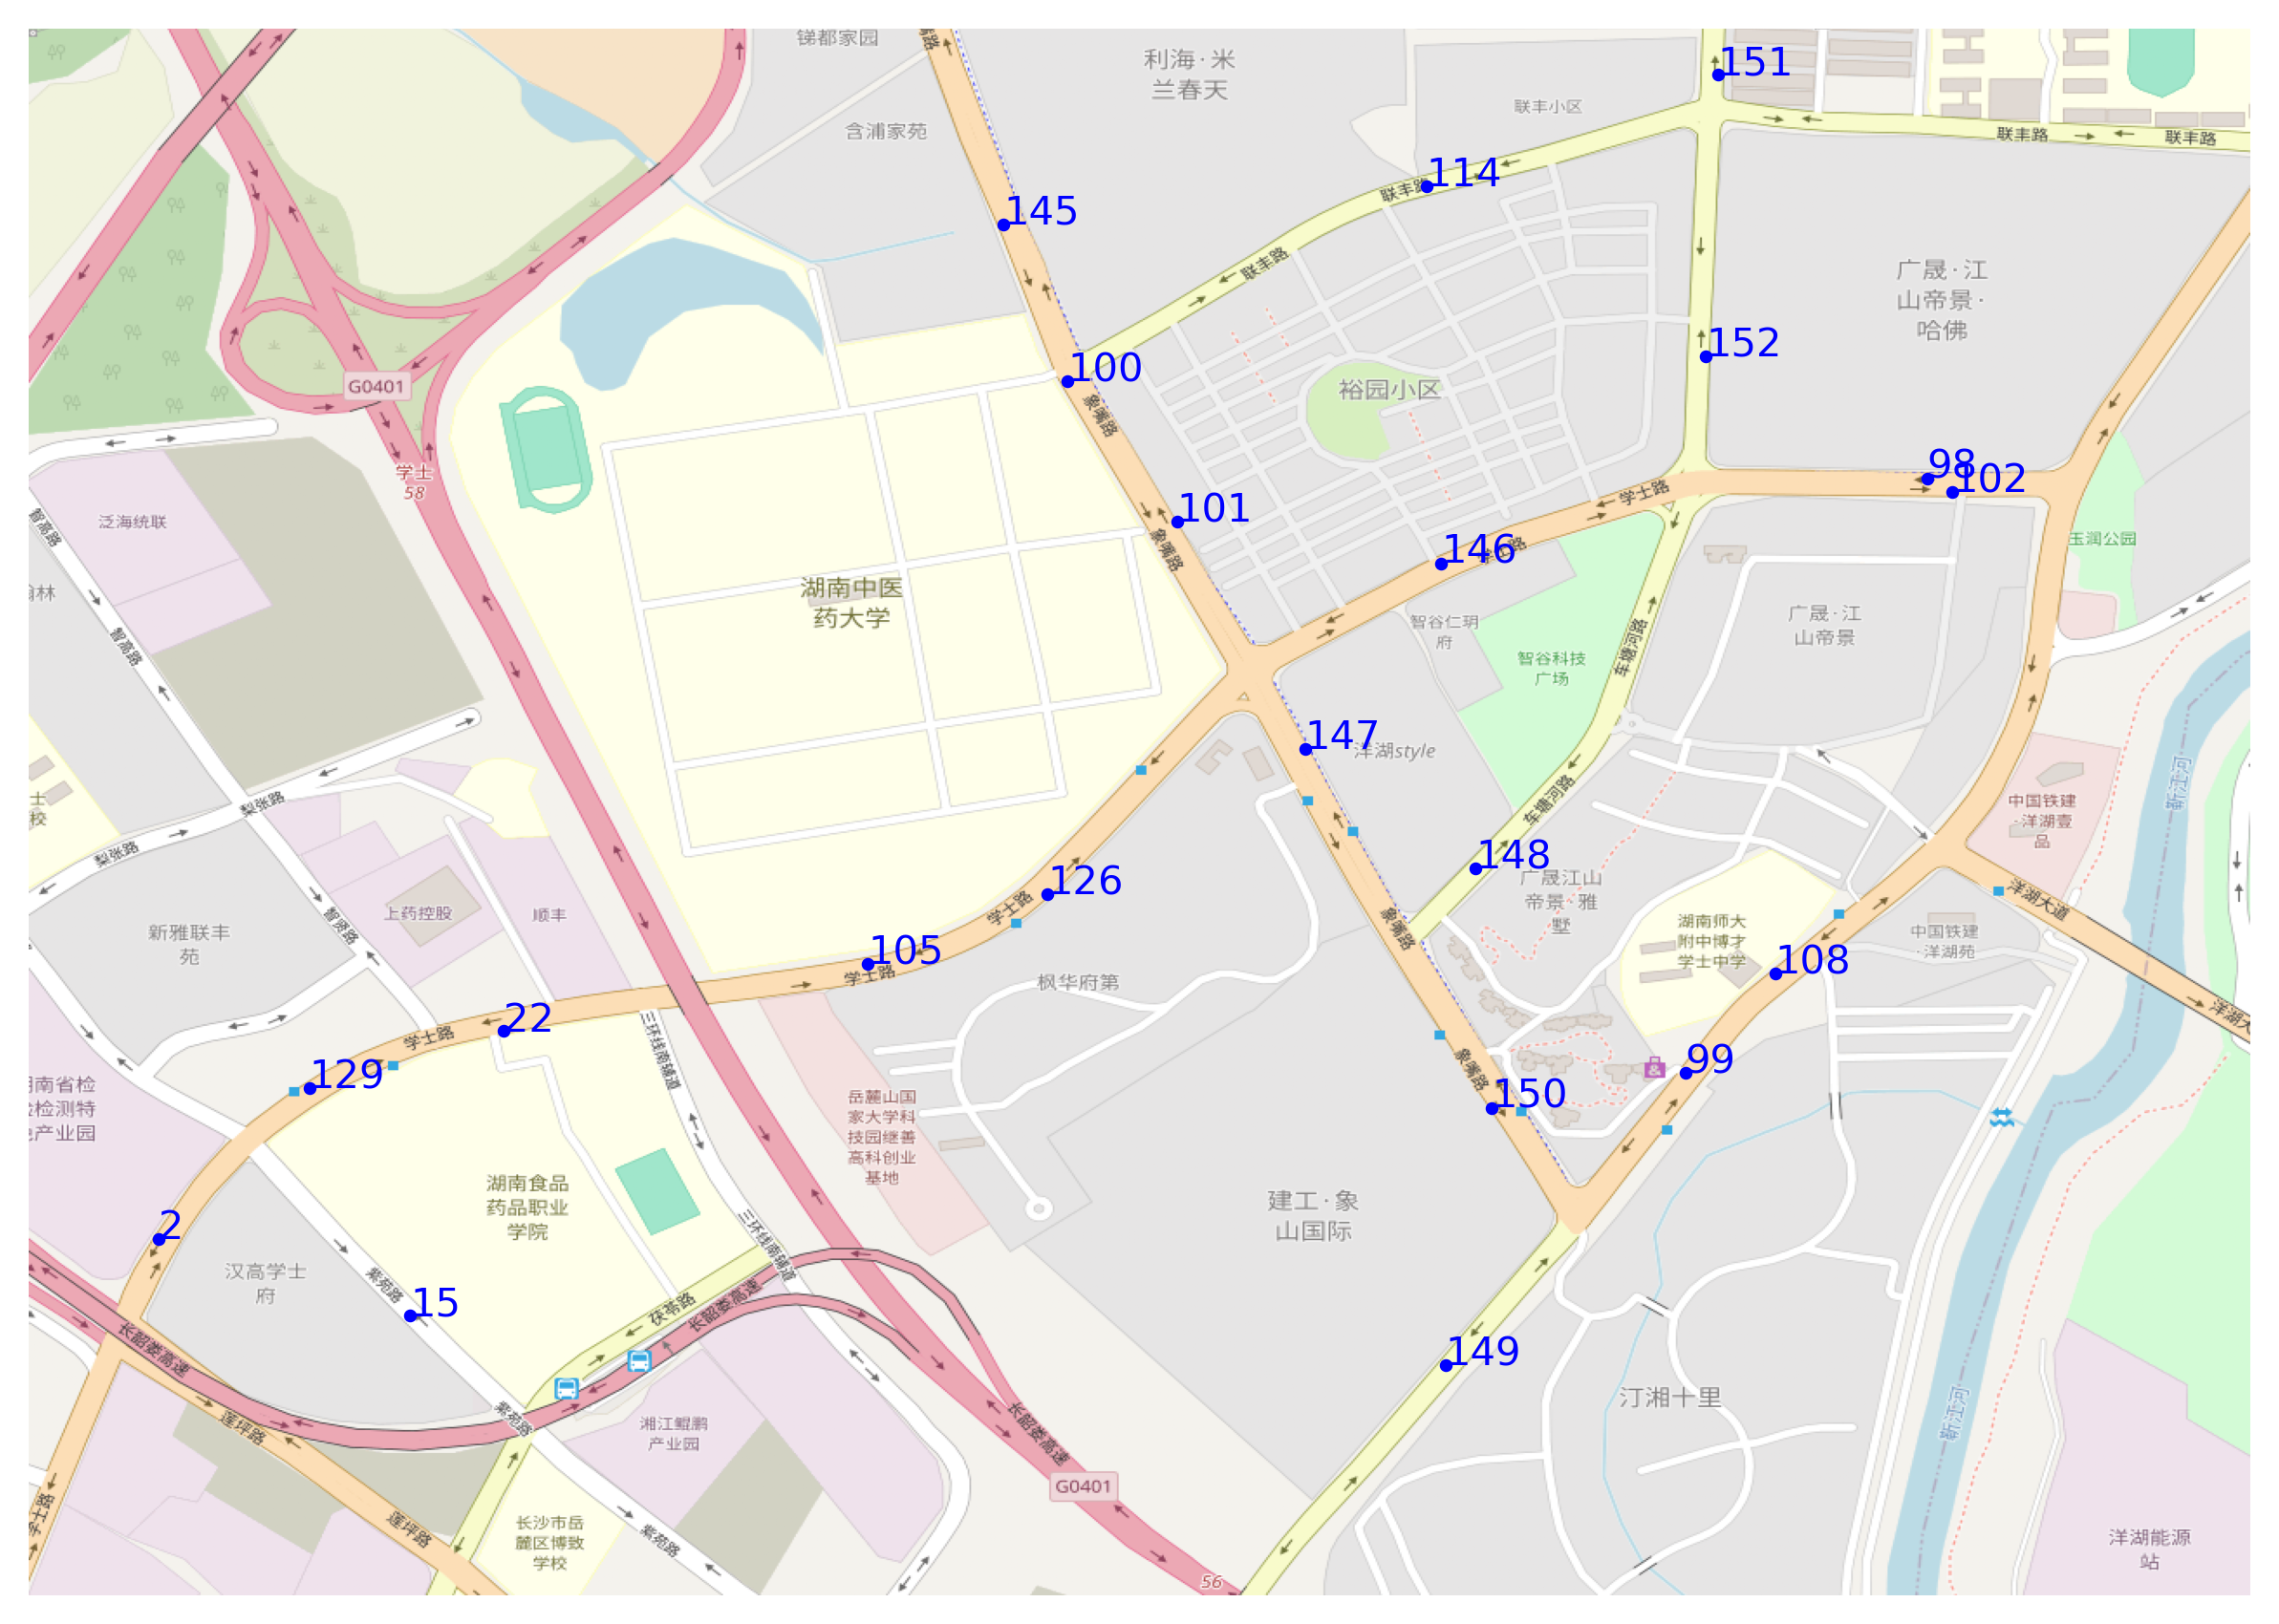

In [4]:
"""
plot region extent
"""
plot_extent = (min(lons), min(lats), max(lons), max(lats))
direname, mapfile = "r1_data", "r1.png"
fig, ax = plot_on_basemap(direname, mapfile, plot_extent, dpi=300, alpha=0.8)
for id, loc in id2loc.items():
    ax.scatter(loc[0], loc[1], c='blue', s=5)
    ax.text(loc[0], loc[1], id, c='blue')
plt.show()

KeyError: 19

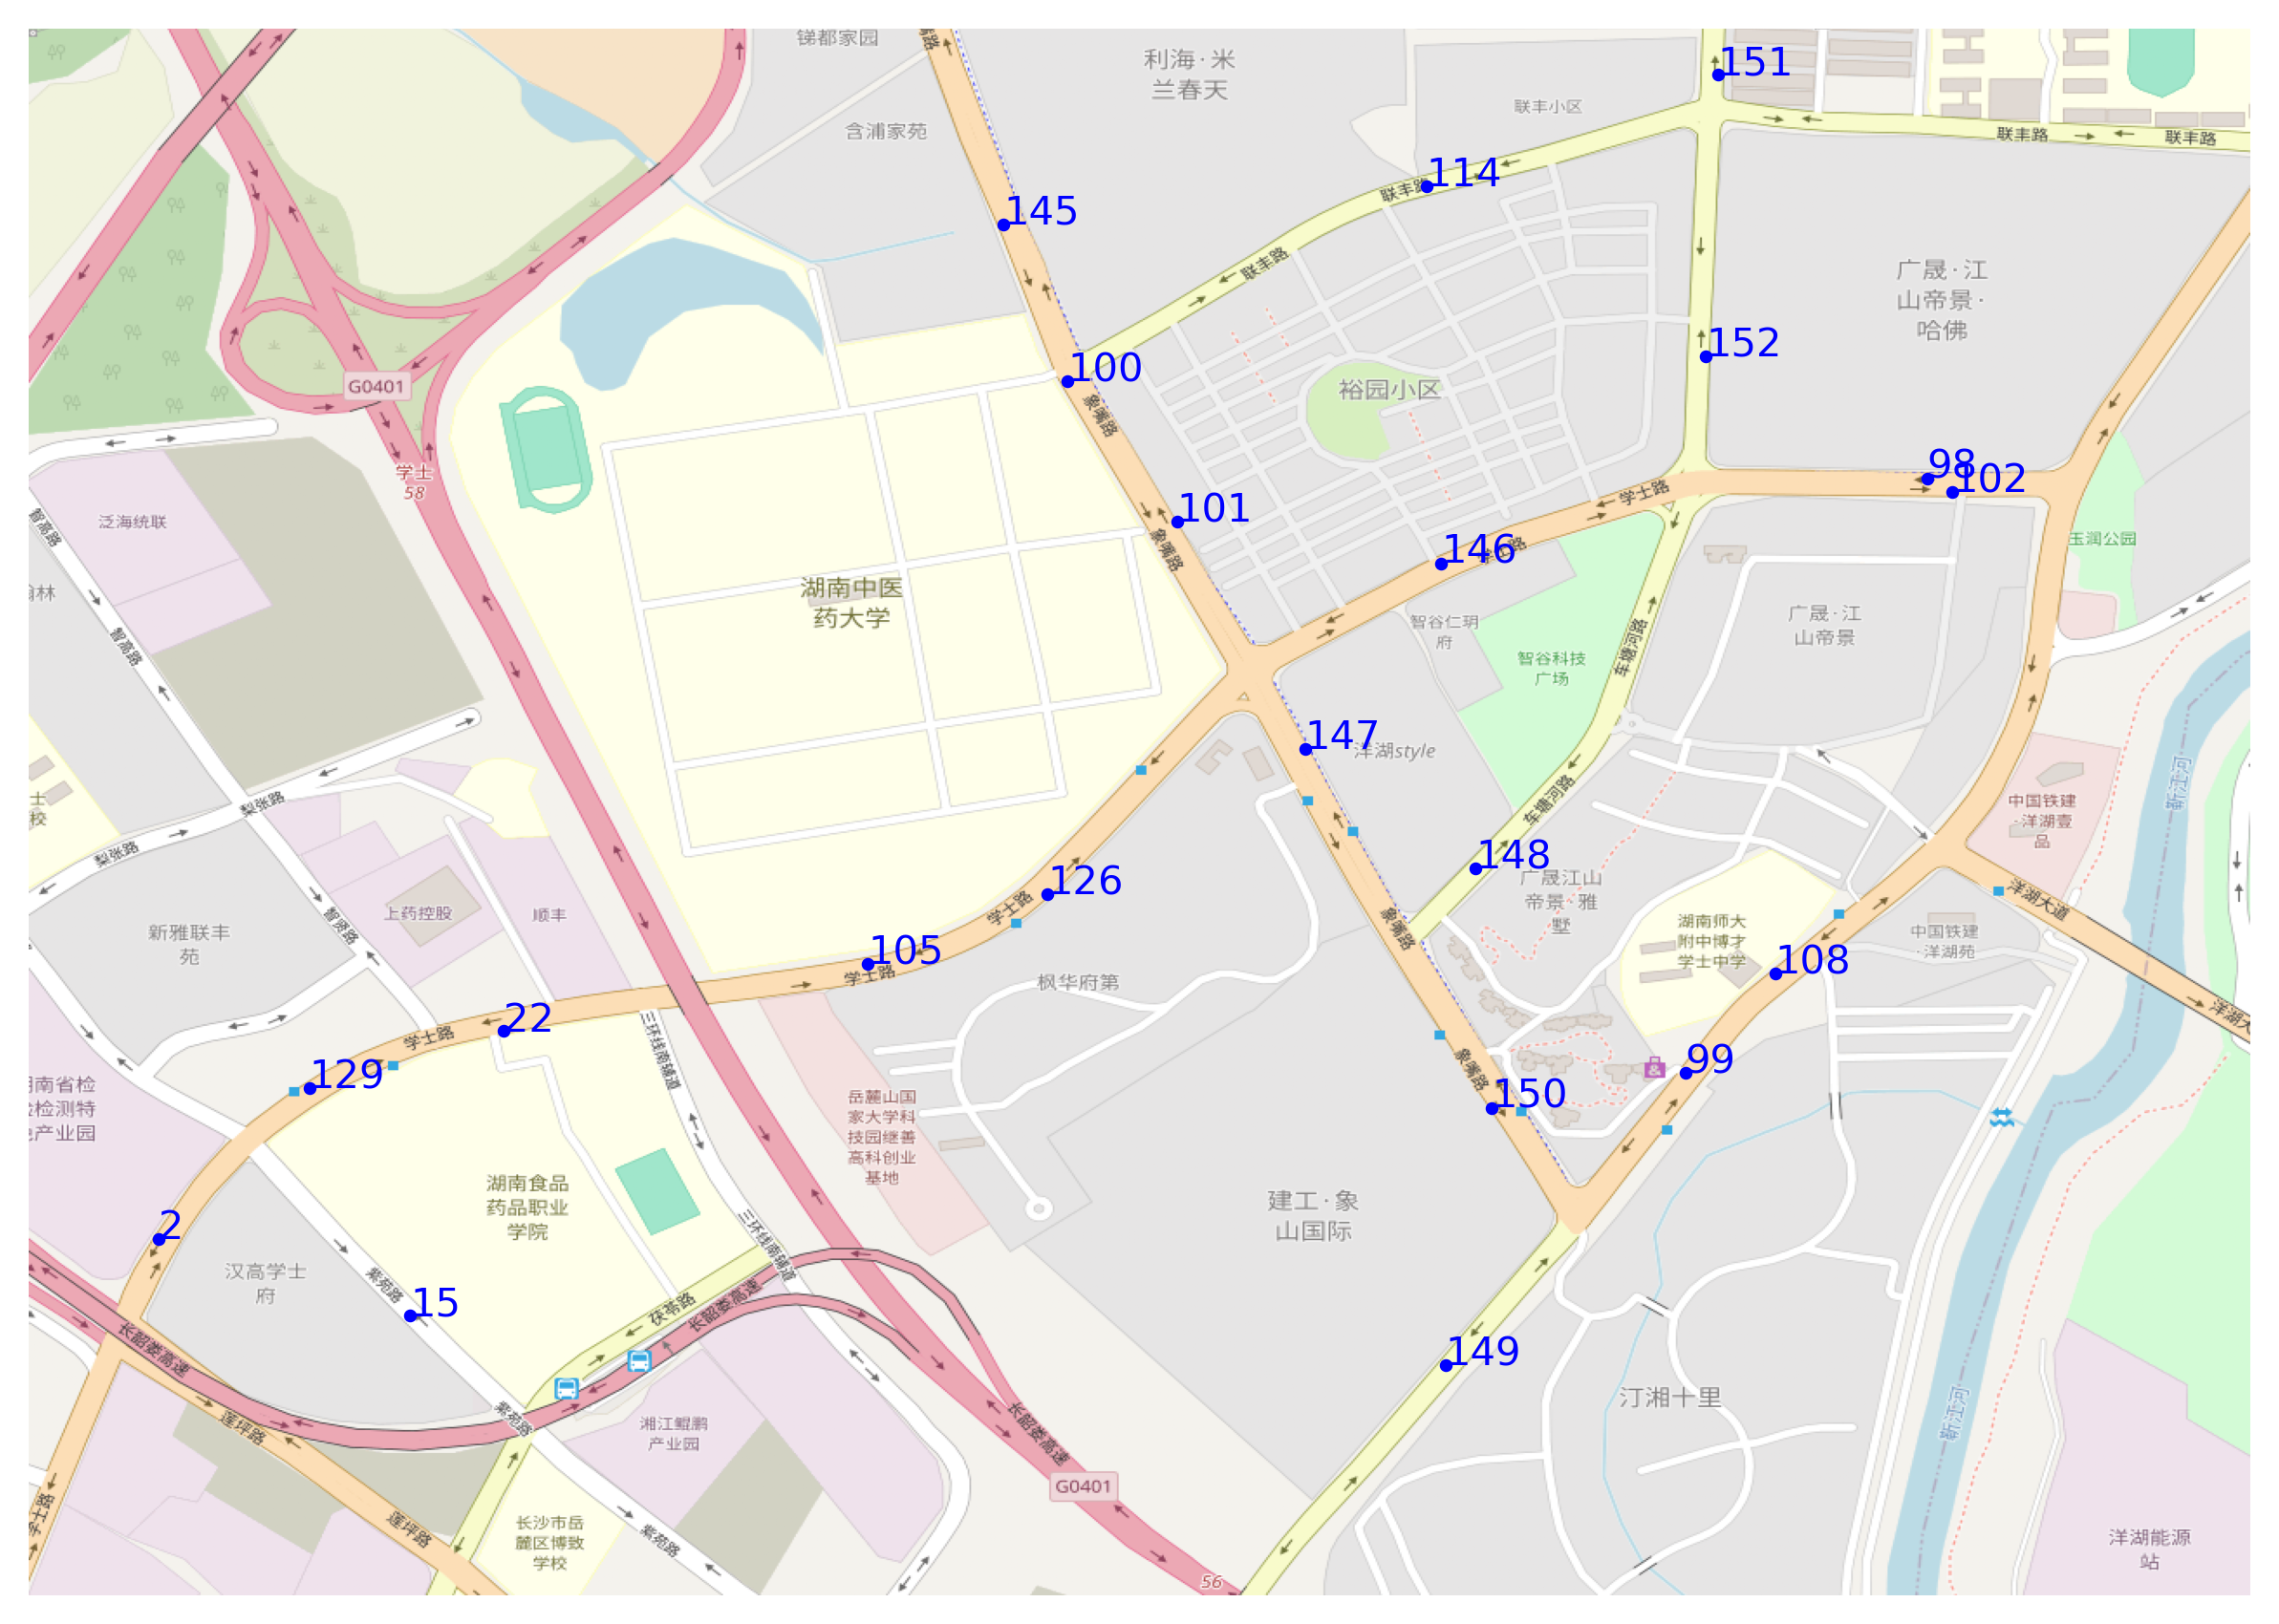

In [5]:
"""
plot order and vehicle information
"""

""" 
obtain vehicle and order data for plotting
"""
LOGID = 6

veh2stat = {}
ord2pstat, ord2dstat = {}, {}
with open(f'History/Test1217-1/log_{LOGID}.json', 'r') as file:
    for row in file.readlines():
        row = eval(row)
        if row['action'] == 'vehicle_location':
            stat = row["data"]["vehicle_location"][0]['station']
            veh = row["data"]["vehicle_location"][0]['vehicle_id']
            veh2stat[veh] = stat
        elif row['action'] == 'order':
            ord = row['data']['order_id']
            pstat = row['data']['available_pickup_station_list'][0]
            dstat = row['data']['available_dropoff_station_list'][0]
            ord2pstat[ord] = pstat
            ord2dstat[ord] = dstat
            
plot_extent = (min(lons), min(lats), max(lons), max(lats))
direname, mapfile = "r1_data", "r1.png"
fig, ax = plot_on_basemap(direname, mapfile, plot_extent, dpi=300, alpha=0.8)

# plot station network
for id, loc in id2loc.items():
    ax.scatter(loc[0], loc[1], c='blue', s=5)
    ax.text(loc[0], loc[1], id, c='blue')

# plot order vector
for ord in ord2pstat:
    ploc = id2loc[ord2pstat[ord]]
    dloc = id2loc[ord2dstat[ord]]
    xs = [ploc[0], dloc[0]]
    ys = [ploc[1], dloc[1]]
    ax.plot(xs, ys, c='orange', lw=1)
    ax.scatter(*ploc, marker='^', s=15, c='green')
    ax.scatter(*dloc, marker='v', s=15, c='green')

# plot vehicle location
for veh,stat in veh2stat.items():
    vloc = id2loc[stat]
    ax.scatter(*vloc, marker='o', s=15, c='red')